# Homework 11


**Concepts covered:**

pandas `DataFrame`s: grouping data, querying `DataFrame`s, joining multiple `DataFrame`s, sampling.

**Instructions:**

Be sure to run each code block after you edit it to make sure it runs as expected. When you are done, we strongly recommend you run all the code from scratch (Runtime menu -> Restart and Run all) to make sure your current code works for all problems.

If your code raises an exception when run from scratch, it will interfere with the auto-grader process causing you to lose some or all points for this homework. Please ask for help on Piazza, attend office hours or schedule an appointment with your learning facilitator if you get stuck.

**Warning about AI:**

It is **strictly forbidden to use any generative AI (e.g., ChatGPT, Claude, Gemini, CoPilot or any similar tools**) to write solutions for any assignment. Students who submit work that is not authentically their own individual work will earn a grade of 0 on this assignment.


**Docstrings and Comments:**

Include a *documentation string* (docstring) for each function definition, as well as comments in the body of your code to explain each control structures (e.g., decision, loop), function call, or formula.

## Shared Imports

Do not install or use any additional modules.
Installing additional modules may result in an autograder failure resulting in zero points for some or all problems.

In [1007]:
# shared imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.close("all")


**Note: This assignment is partially manually graded, so please allow some time for you to get your final scores.**

**Review Problem 1**

**Concept:** *`DataFrame`: initialization, line plots.*

**Task:**


Using the Starbucks stock dataset:

1. Load the `SBUX.csv` dataset into a DataFrame named `df_sbux`.
2. Convert the `date` column to a pandas datetime format and set it as the index.
3. Create a line plot showing both the `high` and `low` prices over time.

Your plot should include:

* both high and low columns plotted together
* a title
* a key


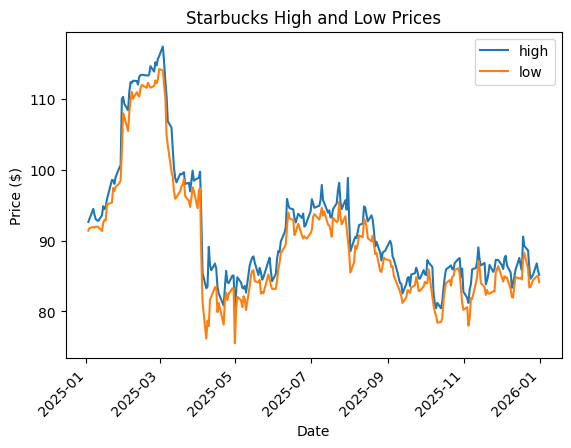

In [1008]:
# Your Solution
# I though also about df["col"].astype(dtype)
df_sbux = pd.read_csv("SBUX.csv")
df_sbux["date"] = pd.to_datetime(df_sbux["date"], unit = "s") # Unix timestamps measured in seconds
df_sbux = df_sbux.set_index("date")

df_sbux[["high", "low"]].plot(title="Starbucks High and Low Prices")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend()
plt.xticks(rotation=45)
plt.show()

Review Problem 2

**Concept:** *`DataFrame`: initialization, descriptive statistics, histogram.*

**Task:**

Using the `SBUX.csv` dataset:

1. Load the dataset into a DataFrame named `df_sbux`.
2. Convert the `date` column to a pandas datetime format and set it as the index.
3. Compute the **daily return** of the stock using the `close` column (percentage change).
4. Display the **descriptive statistics** of the daily returns.
5. Create a **histogram** of the daily returns using 25 bins.
6. Identify **outliers** where the return falls outside of **mean ± 3 standard deviations**.
7. Print:
    *  the upper and lower bounds
    * the number of values above and below these bounds
    * the list of outlier values (sorted by date)


In [1009]:
# df_sbux.head()

In [1010]:
# Your Solution
df_sbux = pd.read_csv("SBUX.csv")
# I could also use method from the elcture df_sbux.index = pd.to_datetime(df_sbux["date"])
df_sbux["date"] = pd.to_datetime(df_sbux["date"], unit = "s") 
df_sbux = df_sbux.set_index("date")
# Better to be safe than sorry, so I decided to sort an index.
df_sbux = df_sbux.sort_index()
# df_sbux["daily_return"] = (df_sbux["close"] - df_sbux["close"].shift(1)) / df_sbux["close"].shift(1)
df_sbux["daily_return"] = df_sbux["close"].pct_change()
#  returns = df_sbux["daily_return"].dropna()
 

In [1011]:
print("Descriptive statistics of daily returns:")
print(df_sbux["daily_return"].describe())

Descriptive statistics of daily returns:
count    249.000000
mean      -0.000130
std        0.021601
min       -0.112162
25%       -0.011336
50%        0.000107
75%        0.011323
max        0.112812
Name: daily_return, dtype: float64


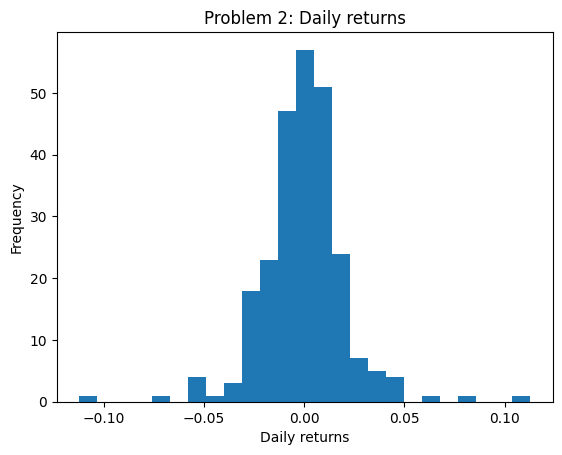

In [1012]:
df_sbux["daily_return"].describe()
fig, ax = plt.subplots()
ax.hist(df_sbux["daily_return"], bins = 25)
ax.set_title("Problem 2: Daily returns")
ax.set_xlabel("Daily returns")
ax.set_ylabel("Frequency")
plt.show()

In [1013]:
mean_return = df_sbux["daily_return"].mean()
std_return = df_sbux["daily_return"].std()

lower_bound = mean_return - 3 * std_return
upper_bound = mean_return + 3 * std_return

# Values below lower bond
below_outliers = df_sbux["daily_return"][df_sbux["daily_return"] < lower_bound]

# Values above upper bound
above_outliers = df_sbux["daily_return"][df_sbux["daily_return"] > upper_bound]

# All outliers sorted by date
all_outliers = df_sbux["daily_return"][(df_sbux["daily_return"] < lower_bound) | (df_sbux["daily_return"] > upper_bound)].sort_index()

In [1014]:
# Print results
print("\nOutlier detection:")
print(f"Lower bound: {lower_bound}")
print(f"Upper bound: {upper_bound}")

print(f"\nNumber of values below lower bound: {len(below_outliers)}")
print(f"Number of values above upper bound: {len(above_outliers)}")

print("\nList of outlier values sorted by date:")
print(all_outliers)


Outlier detection:
Lower bound: -0.06493212818695372
Upper bound: 0.06467188888830804

Number of values below lower bound: 2
Number of values above upper bound: 3

List of outlier values sorted by date:
date
2025-01-29 14:30:00    0.081366
2025-04-03 13:30:00   -0.112162
2025-04-04 13:30:00   -0.069794
2025-04-09 13:30:00    0.112812
2025-05-12 13:30:00    0.066874
Name: daily_return, dtype: float64


Test case for problem 2

In [1015]:
# Test Case:



**Problem 3**

**Concept:** *Grouping Data, plotting*


**Task:**

Using the `02215_weather.csv` dataset:

1. Load the dataset into a DataFrame named `df_weather`.
2. Convert the `datetime` column to a pandas datetime format and set it as the index.
3. Use the icon column as a categorical variable and group the data by `icon`.
4. Create a **pie chart** showing the count of each weather icon category.

Your chart should include:
* labels for each category
* a title



In [1016]:
# Your Solution

df_weather = pd.read_csv("02215_weather.csv")
df_weather.head()

,datetime,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,precip,...,solarenergy,uvindex,severerisk,sunrise,sunset,moonphase,conditions,description,icon,stations
0,1/1/21,2.4,-2.4,0.5,2.3,-6.8,-1.9,-5.4,65.0,0.897,...,4.8,3,NaN,2021-01-01T07:13:45,2021-01-01T16:22:48,0.53,"Snow, Rain, Partially cloudy",Partly cloudy throughout the day with late aft...,rain,"KOWD,AV085,72509854704,KBED,0518W,KBOS,7250901..."
1,1/2/21,6.0,0.1,3.9,3.8,-5.1,-0.4,1.6,85.7,12.092,...,2.4,1,NaN,2021-01-02T07:13:48,2021-01-02T16:23:41,0.56,"Snow, Rain, Partially cloudy",Partly cloudy throughout the day with rain or ...,rain,"KOWD,AV085,72509854704,KBED,0518W,KBOS,7250901..."
2,1/3/21,1.7,-1.4,0.1,-1.7,-5.7,-3.8,-3.0,79.7,0.794,...,1.5,1,NaN,2021-01-03T07:13:49,2021-01-03T16:24:36,0.60,"Snow, Rain, Partially cloudy",Partly cloudy throughout the day with rain or ...,snow,"KOWD,72509854704,KBED,0518W,KBOS,72509014739,7..."
3,1/4/21,4.0,-0.6,1.0,-0.3,-5.7,-3.5,-2.3,78.9,0.000,...,4.3,3,NaN,2021-01-04T07:13:47,2021-01-04T16:25:33,0.65,Partially cloudy,Partly cloudy throughout the day.,snow,"KOWD,AV085,72509854704,KBED,0518W,KBOS,7250901..."
4,1/5/21,0.8,-1.0,-0.3,-3.9,-6.1,-4.8,-2.7,83.1,0.267,...,2.6,1,NaN,2021-01-05T07:13:43,2021-01-05T16:26:31,0.70,"Snow, Rain, Overcast",Cloudy skies throughout the day with afternoon...,rain,"KOWD,72509854704,KBED,0518W,KBOS,72509014739,7..."


In [1017]:
df_weather["datetime"] = pd.to_datetime(df_weather["datetime"], format="%m/%d/%y") # I can seay to pandas to read the text as a partciular format month / day / 2-digit year
df_weather = df_weather.set_index("datetime").sort_index()

In [1018]:
icon_cat = df_weather.groupby(df_weather["icon"]) 
icon_counts = icon_cat.size()

In [1019]:
icon_counts.index

Index(['clear-day', 'cloudy', 'partly-cloudy-day', 'rain', 'snow', 'wind'], dtype='object', name='icon')

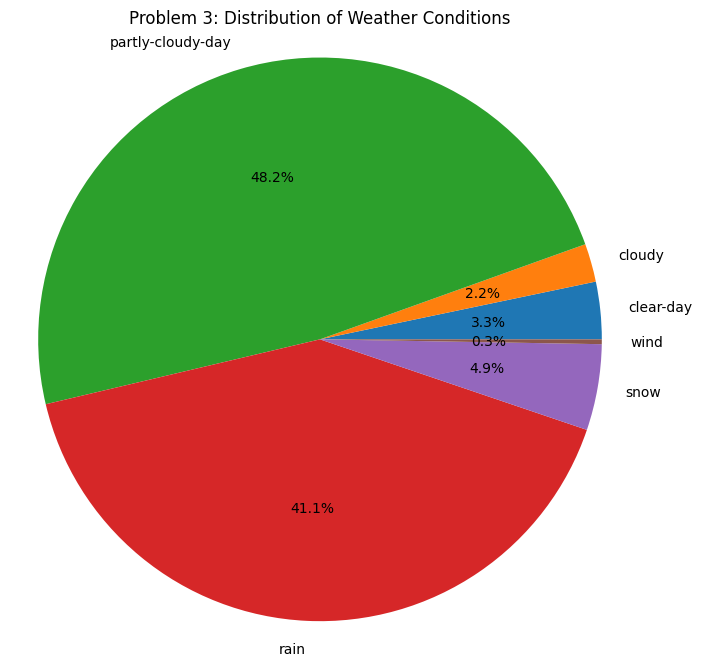

In [1020]:
# Pie needs counts, not the raw text column so we should use:
# icon_cat = df_weather.groupby("icon").size() or
# icon_cat = df_weather["icon"].value_counts()
fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(icon_counts, labels = icon_counts.index, autopct="%1.1f%%")
# ax.legend()
ax.set_title("Problem 3: Distribution of Weather Conditions")
ax.axis("equal")
plt.show()

**Problem 4**

**Concept:** *Grouping Data, plotting*


**Task:**

Using the `02215_weather.csv` dataset:

1. Use the existing grouped object based on the `icon` column from **Problem 3**.
2. Create a **histogram** of the `tempmax` column for each weather condition group.

Your plot should include:
* 25 bins
* transparency so overlapping distributions can be seen
* a legend
* a title


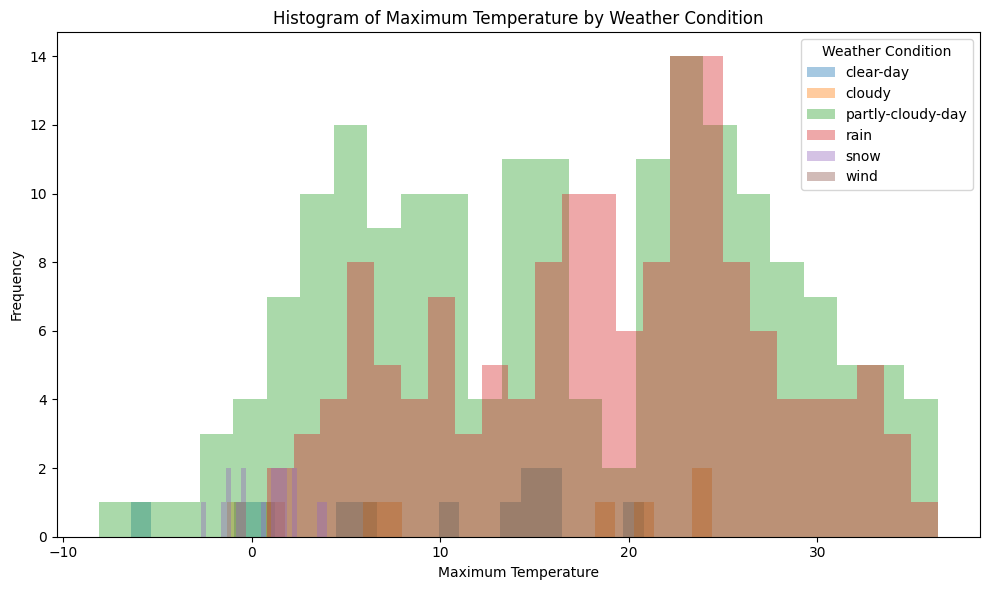

In [1021]:
# Your Solution
icon_cat = df_weather.groupby(df_weather["icon"]) 

fig, ax = plt.subplots(figsize=(10, 6))

for icon_name, group in icon_cat:
    ax.hist(group["tempmax"], bins=25, alpha=0.4, label=icon_name)

ax.legend(title="Weather Condition")
ax.set_title("Histogram of Maximum Temperature by Weather Condition")
ax.set_xlabel("Maximum Temperature")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()


In [1022]:
# Below is my first attempt, but then I saw that we have to set alpha, so I have to provide each histogram n the same ax
# df = pd.read_csv("02215_weather.csv")
# icon_object = df.groupby(df["icon"]) 

# fig, ax = plt.subplots(len(icon_object), 1, figsize = (10,10))

# for i, (icon_name, group) in enumerate(icon_object):
#     ax[i].hist(group["tempmax"], bins=25, alpha=0.5, label=icon_name)
#     ax[i].legend()
#     ax[i].set_title(icon_name)

# plt.tight_layout()
# plt.show()

**Problem 5**

**Concept:** *Grouping Data, plotting*


**Task:**

Using the `02215_weather.csv` dataset:

1. Use the existing grouped object based on the `icon` column from **Problem 3**.
2. Create a histogram of the `precip` column for each weather condition group.

Your plot should include:

* 10 bins
* transparency so overlapping distributions can be seen
* a legend
* a title



In [1023]:
# df_weather.columns

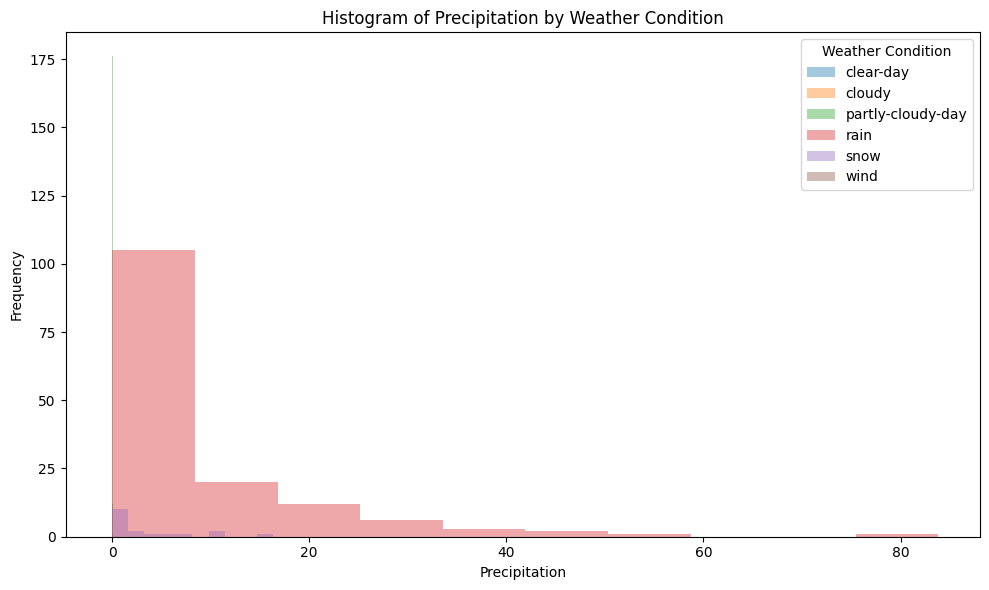

In [1024]:
# Your Solution

icon_cat = df_weather.groupby(df_weather["icon"]) 

fig, ax = plt.subplots(figsize=(10, 6))

for icon_name, group in icon_cat:
    ax.hist(group["precip"], bins=10, alpha=0.4, label=icon_name)

ax.legend(title="Weather Condition")
ax.set_title("Histogram of Precipitation by Weather Condition")
ax.set_xlabel("Precipitation")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()


**Problem 6**

**Concept:** *Grouping Data, plotting*


**Task:**


Using the `02215_weather.csv` dataset:

1. Use the existing grouped object based on the `icon` column from **Problem 3**.
2. Compute the **mean** of the `tempmax` column for each weather condition group.
3. Create a **bar chart** to display the mean maximum temperature for each group.


Your plot should include:

* one bar for each weather icon category
* a title



In [1025]:
# icon_cat["tempmax"].mean()

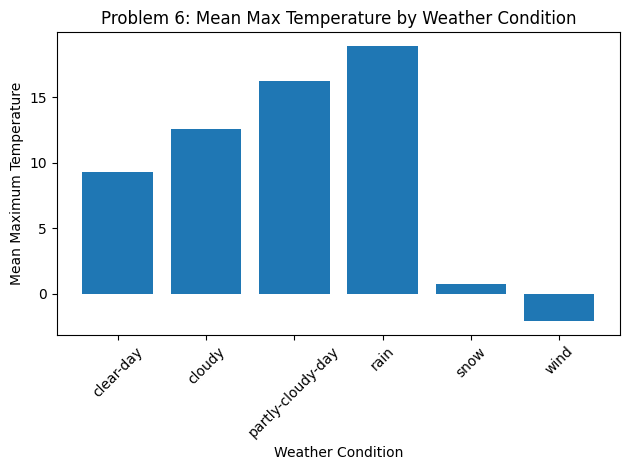

In [1026]:
# Your Solution

icon_cat = df_weather.groupby("icon")
group_mean_tempmax = icon_cat["tempmax"].mean()

fig, ax = plt.subplots()
ax.bar(group_mean_tempmax.index, group_mean_tempmax)
ax.set_title("Problem 6: Mean Max Temperature by Weather Condition")
ax.set_xlabel("Weather Condition")
ax.set_ylabel("Mean Maximum Temperature")
ax.tick_params(axis="x", labelrotation=45)
plt.tight_layout()
plt.show()

**Problem 7**

**Concept:** *Grouping data, descriptive statistics*


**Task:**

Using the `02215_weather.csv` dataset:

1. Group the DataFrame by the `icon` column and store the result in a variable named `grouped_by_icon`.
2. Compute descriptive statistics for the `tempmax` column for each group and store the result in a variable named `grouped_tempmax_statistics`.
3. Compute descriptive statistics for the `precip` column for each group and store the result in a variable named `grouped_precipitation_statistics`.
4. Compute the **mean** of the `tempmax` column for each group and store the result in a variable named `grouped_tempmax_mean`.

Print all three results with clear labels:
* `"Tempmax grouped by conditions"`
* `"Precipitation grouped by conditions"`
* `"Mean of tempmax grouped by conditions"`


In [1027]:
# Your Solution

grouped_by_icon = df_weather.groupby("icon") 

grouped_tempmax_statistics = grouped_by_icon["tempmax"].describe()
grouped_precipitation_statistics = grouped_by_icon["precip"].describe()
grouped_tempmax_mean = grouped_by_icon["tempmax"].mean()

print(f"Tempmax grouped by conditions:\n\n{grouped_tempmax_statistics}\n")
print(f"Precipitation grouped by conditions:\n\n{grouped_precipitation_statistics}\n")
print(f"Mean of tempmax grouped by conditions:\n\n{grouped_tempmax_mean}")

Tempmax grouped by conditions:

                   count       mean        std  min    25%    50%     75%  \
icon                                                                        
clear-day           12.0   9.316667   8.230965 -6.4   4.15  12.10  15.225   
cloudy               8.0  12.575000  10.423565 -1.3   4.95  13.05  21.350   
partly-cloudy-day  176.0  16.246023  10.533554 -8.1   7.20  15.65  25.000   
rain               150.0  18.904000   8.498037  0.8  12.60  19.90  24.600   
snow                18.0   0.750000   1.805628 -2.7  -0.65   1.25   1.775   
wind                 1.0  -2.100000        NaN -2.1  -2.10  -2.10  -2.100   

                    max  
icon                     
clear-day          20.8  
cloudy             24.4  
partly-cloudy-day  36.4  
rain               36.4  
snow                4.0  
wind               -2.1  

Precipitation grouped by conditions:

                   count      mean        std    min      25%     50%  \
icon                           

QUERYING

The following data frame will be used in several questions.


In [1028]:
# starter code
df_voter_data = pd.read_csv("https://raw.githubusercontent.com/bu-cds-dx602/homework/main/week-11/newton_voters.csv", low_memory=False)
df_voter_data.index = df_voter_data["Voter ID Number"]
df_voter_data['Date of Birth'] = pd.to_datetime(df_voter_data['Date of Birth'])

**Problem 8**

**Concept:** *Querying `DataFrame`s and graphing*


**Task:**

Using the `df_voter_data` DataFrame:
1. Determine the **total number of voters** and print the result.
2. Compute the count of voters in each **Party Affiliation** category.
3. Create a **pie chart** showing the distribution of voters by party affiliation.

Your plot should include:
* labels for each category
* a title that includes the total number of voters


In [1029]:
# df_voter_data

The total number of voters is 58769
The count of voters in each Party Affiliation category is: Party Affiliation
U     32416
D     23108
R      2854
CC      110
L       103
J        28
T        27
O        22
A        20
Q        19
S        14
G        10
X         8
AA        7
Z         5
FF        4
GG        3
V         2
K         2
HH        1
E         1
P         1
H         1
Y         1
W         1
EE        1
Name: count, dtype: int64


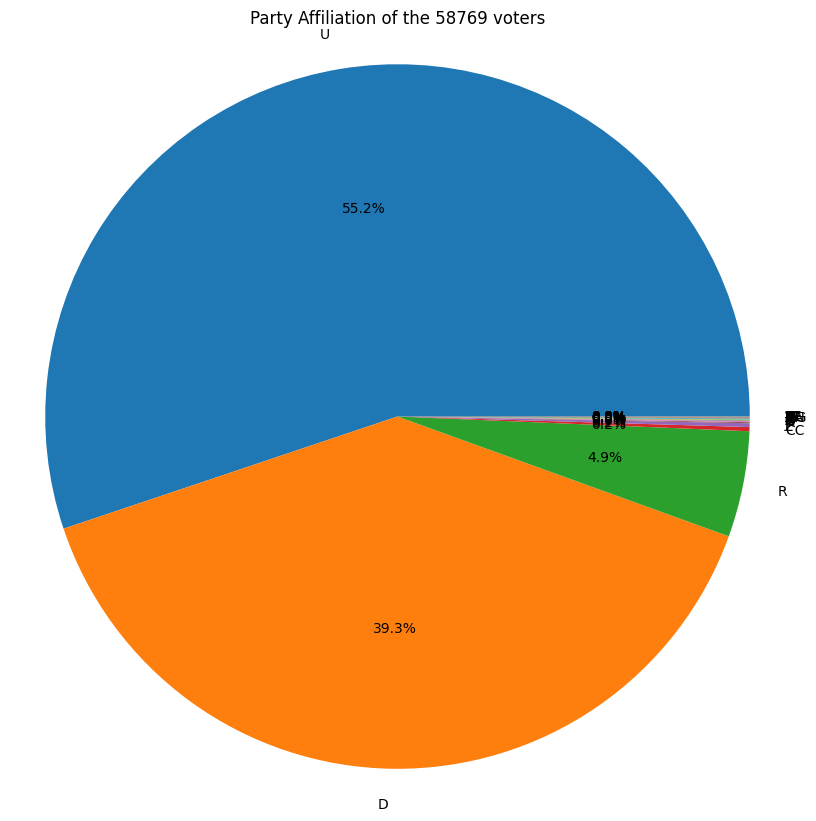

In [1030]:
# Your Solution

tot_voters = pd.unique(df_voter_data['Voter ID Number']).size
print(f"The total number of voters is {tot_voters}")

group_affil_size = df_voter_data["Party Affiliation"].value_counts()
print(f"The count of voters in each Party Affiliation category is: {group_affil_size}")

fig, ax = plt.subplots(figsize = (10, 10))
ax.pie(group_affil_size, labels = group_affil_size.index, autopct="%1.1f%%")
ax.set_title(f"Party Affiliation of the {tot_voters} voters")
ax.axis("equal")
plt.show()

**Problem 9**

**Concept:** *Querying `DataFrame`s and graphing*


**Task:**

Using the `df_voter_data` DataFrame:
1. Create a new DataFrame named `df_older_voters` that includes only voters born **before January 1, 1950**.
    * Use the `.query()` method
    * Note: use backticks for column names containing spaces
2. Print the total number of voters in this filtered dataset.
3. Compute the count of voters in each **Party Affiliation** category for this subset.
4. Create a **pie chart** showing the distribution of party affiliations among these older voters.

Your plot should include:
* labels for each category
* a title that includes the number of older voters


In [1031]:
# df_voter_data

The total number of older voters is 9073
The count of voters in each Party Affiliation category is: Party Affiliation
U     4381
D     4141
R      520
CC      14
L        5
T        4
O        2
Z        1
Q        1
A        1
AA       1
J        1
K        1
Name: count, dtype: int64


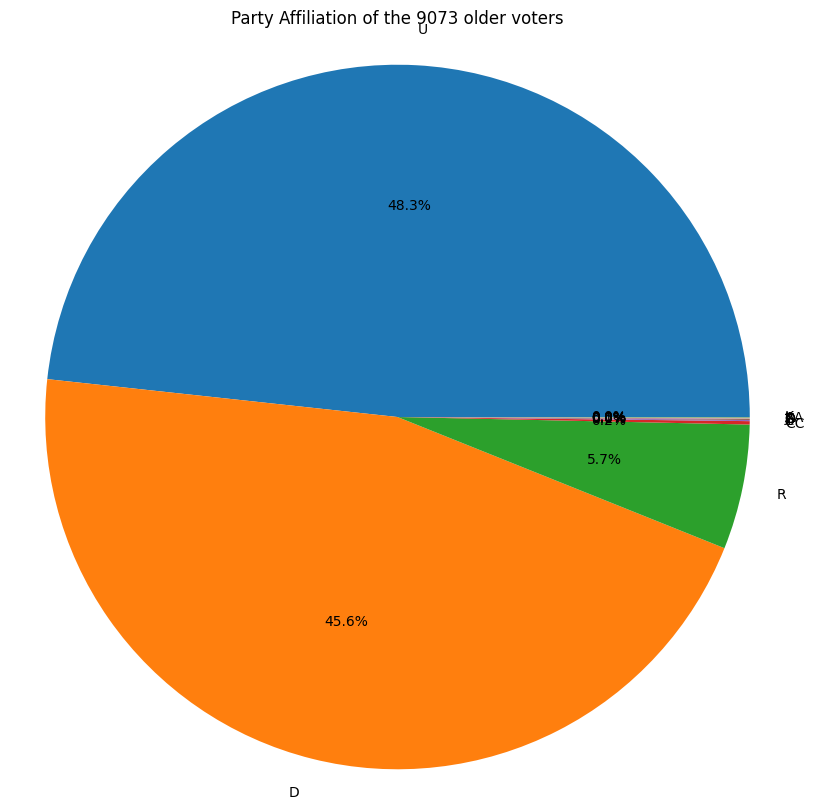

In [1032]:
# Your Solution
df_older_voters = df_voter_data.query("`Date of Birth` < '1950-01-01'")
print(f"The total number of older voters is {len(df_older_voters)}")

group_affil_size = df_older_voters["Party Affiliation"].value_counts()
print(f"The count of voters in each Party Affiliation category is: {group_affil_size}")

fig, ax = plt.subplots(figsize = (10, 10))
ax.pie(group_affil_size, labels = group_affil_size.index, autopct="%1.1f%%")
ax.set_title(f"Party Affiliation of the {len(df_older_voters)} older voters")
ax.axis("equal")
plt.show()

**Problem 10**

**Concept:** *Querying `DataFrame`s and graphing*


**Task:**

Using the `df_voter_data` DataFrame:
1. Create a new DataFrame named `df_younger_voters` that includes only voters born **after January 1, 2000**.
    * Use the `.query()` method
    * Note: use backticks for column names containing spaces
2. Print the total number of voters in this filtered dataset.
3. Compute the count of voters in each **Party Affiliation** category for this subset.
4. Create a **pie chart** showing the distribution of party affiliations among these Younger voters.

Your plot should include:
* labels for each category
* a title that includes the number of younger voters


In [1033]:
# pd.Timestamp("2000-01-01")

The total number of younger voters is 5099
The count of voters in each Party Affiliation category is: Party Affiliation
U     3533
D     1406
R      126
L       17
S        4
CC       3
A        2
J        2
HH       1
P        1
G        1
GG       1
AA       1
X        1
Name: count, dtype: int64


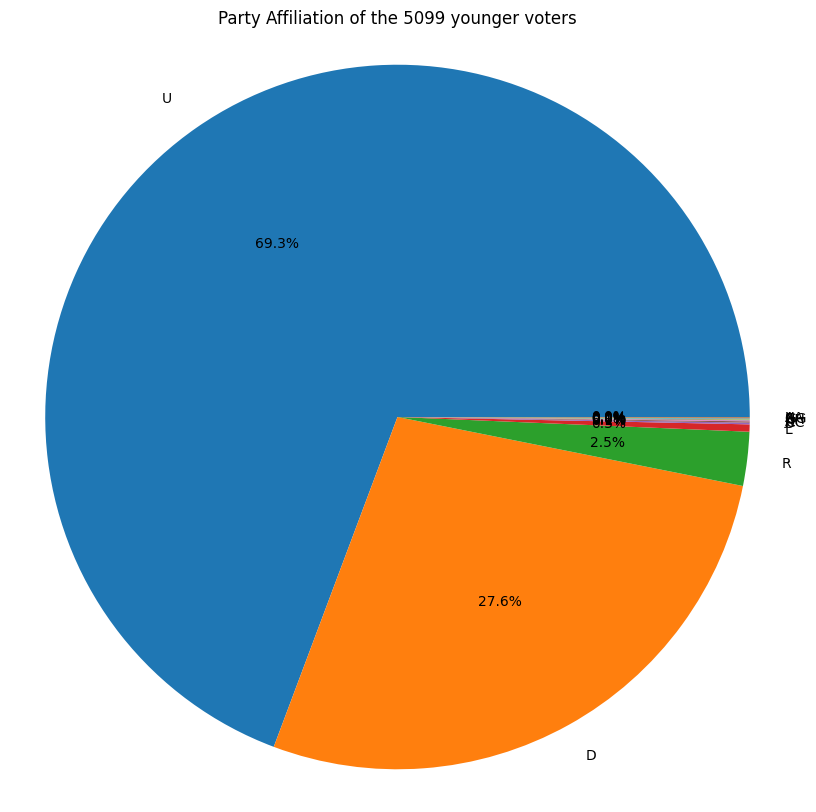

In [1034]:
# Your Solution
# I will try using variable this time. It will allow me to comapre datetime to datetime not to string
cutoff = pd.Timestamp("2000-01-01")
df_younger_voters = df_voter_data.query("`Date of Birth` > @cutoff")
print(f"The total number of younger voters is {len(df_younger_voters)}")

group_affil_size = df_younger_voters["Party Affiliation"].value_counts()
print(f"The count of voters in each Party Affiliation category is: {group_affil_size}")

fig, ax = plt.subplots(figsize = (10, 10))
ax.pie(group_affil_size, labels = group_affil_size.index, autopct="%1.1f%%")
ax.set_title(f"Party Affiliation of the {len(df_younger_voters)} younger voters")
ax.axis("equal")
plt.show()


**Problem 11**

**Concept:** *Querying `DataFrame`s and graphing*



**Task:**

Using the `df_voter_data` DataFrame:
1. Identify all columns related to elections:
    * Select columns whose names contain the letter `"v"` but do **not** contain `"score"`
    * Store the result in a variable named `election_columns`

2. Compute the **voting participation percentage** for each election among all voters:
    * Store the result in a variable named `d1`
    * **Hint:** To calculate participation
        * Use `.sum()` on a column to count how many voters participated
        * Divide by the total number of voters using `len(df)`
        * Multiply by 100 to convert to a percentage

3. Create a filtered DataFrame named `df_high_voter_score`:
    * Include only voters with `voter_score >= 4`
    * Print the number of voters in this group

4. Compute the **voting participation percentage** for this group:
    * Store the result in a variable named `d2`

5. Create a filtered DataFrame named `df_unenrolled`:
    * Include only voters with `"Party Affiliation" == "U "`
    * Print the number of voters in this group

6. Compute the voting participation percentage for this group:
    * Store the result in a variable named `d3`

7. Combine the results into a new DataFrame named `d`:
    * Index should be the election columns
    * Columns should be:
        * `"all voters"`
        * `"high-propensity voters"`
        * `"unenrolled voters"`

8. Create a **bar chart** from this combined DataFrame.

Your plot should include:
* a title
* a key

Number of the voters with score equal or greater than 4: 15245
Number of the voters with U Party Affiliation: 32416


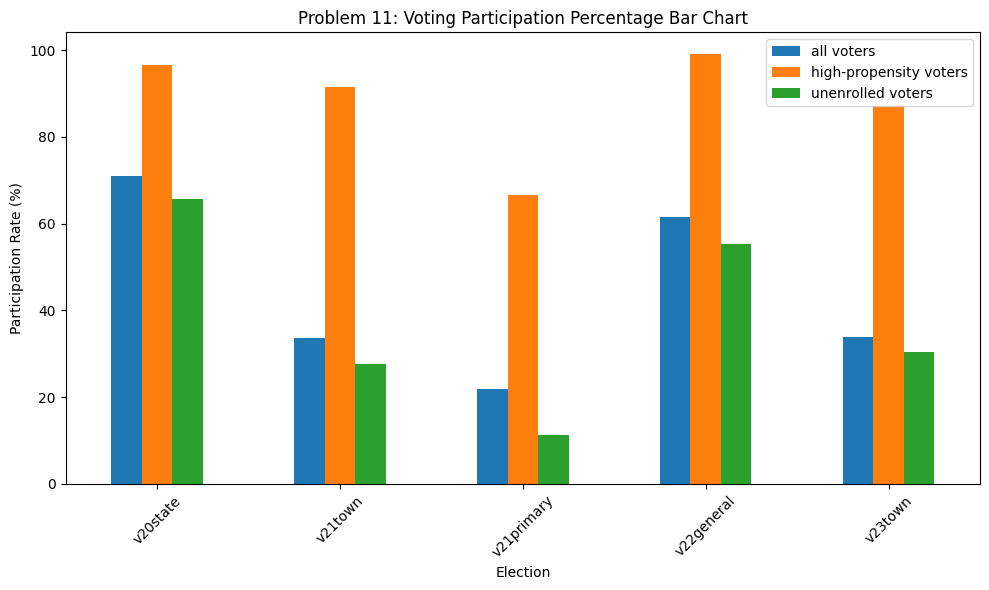

In [1035]:
# Your Solution

election_columns = [col for col in df_voter_data.columns if "v" in col.lower() and "score" not in col.lower()] # There are uppercase letters.
new_df = df_voter_data[election_columns].drop(columns="Voter ID Number")
d1 = new_df.mean() * 100

df_high_voter_score = df_voter_data.query("`voter_score` >= 4")
print(f"Number of the voters with score equal or greater than 4: {len(df_high_voter_score)}")

d2 = df_high_voter_score[election_columns].drop(columns="Voter ID Number").mean() * 100

df_unenrolled = df_voter_data[df_voter_data["Party Affiliation"].str.strip() == "U"] # We should renove whitespaces
print(f"Number of the voters with U Party Affiliation: {len(df_unenrolled)}")

d3 = df_unenrolled[election_columns].drop(columns="Voter ID Number").mean() * 100

d = pd.DataFrame({"all voters": d1, "high-propensity voters": d2, "unenrolled voters": d3})

fig, ax = plt.subplots(figsize=(10, 6))
d.plot.bar(ax=ax)
ax.set_title("Problem 11: Voting Participation Percentage Bar Chart")
ax.set_xlabel("Election")
ax.set_ylabel("Participation Rate (%)")
ax.tick_params(axis="x", labelrotation=45)
plt.tight_layout()

plt.show()

**Problem 12**

**Concept:** *Joining `DataFrame`s*


**Task:**

You are given two DataFrames:
* `submissions`, which contains student IDs and their homework submission IDs
* `grades`, which contains homework grades indexed by submission ID

Using these DataFrames:
1. Inspect both DataFrames by printing them.
2. Join the `submissions` DataFrame with the `grades` DataFrame:
    * Match the `hw1_submission` column in `submissions` with the index of `grades`
    * Store the result in a variable named `result`
3. Update the index of the resulting DataFrame:
    * Set the index to the `student_id` column
4. Create a new DataFrame named `result_df`:
    * Remove the `student_id` column
5. Print the final DataFrame


Starter code:

In [1036]:
# STARTER CODE:
submissions = pd.DataFrame(data={"student_id": ["U100", "U101", "U102", "U103", "U104"],
                        "hw1_submission": ["c1325", "b231", "a512", "e9999", "d8234"]})

grades = pd.DataFrame(index=["a512", "b231", "c1325", "d8234", "e9999"],
                        data={"hw1_grade": [0.99, 0.50, 0.62, 0.78, 1.00]} )


In [1037]:
# Your Solution
print("submissions:")
print(submissions)

print("\ngrades:")
print(grades)

result_df = submissions.merge(
    grades,
    left_on="hw1_submission",
    right_index=True,
    how="inner",
    validate="1:1"
).set_index("student_id")

print(f"\nFinal merged dataset on student_id: \n\n{result_df}")

submissions:
  student_id hw1_submission
0       U100          c1325
1       U101           b231
2       U102           a512
3       U103          e9999
4       U104          d8234

grades:
       hw1_grade
a512        0.99
b231        0.50
c1325       0.62
d8234       0.78
e9999       1.00

Final merged dataset on student_id: 

           hw1_submission  hw1_grade
student_id                          
U100                c1325       0.62
U101                 b231       0.50
U102                 a512       0.99
U103                e9999       1.00
U104                d8234       0.78


**Problem 13**

**Concept:** *Joining `DataFrame`s*



**Task:**

You are given two datasets:
* `design_materials.tsv`, which contains materials and the quantity required per bed
* `material_costs.tsv`, which contains the cost per unit for each material

Using these datasets:
1. Load both datasets from the provided `.tsv` files using the correct separator.
2. Merge the two DataFrames:
    * Join on the `material` column
    * Store the result in a variable named `df_costs`
3. Create a new column named `cost`:
    * Compute it as:

      **quantity_per_bed × unit_cost**
4. Print the resulting DataFrame

In [1038]:
# Your Solution
material_cost = pd.read_csv("material_costs.tsv", sep ="\t")
design_materials = pd.read_csv("design_materials.tsv", sep ="\t")

df_costs = design_materials.merge(
    material_cost, 
    how = "left", # easier for debugging than inner
    on = "material", 
    validate = "m:1"
)

df_costs["cost"] = df_costs["quantity_per_bed"] * df_costs["unit_cost"]

print(df_costs)

          design                    material  quantity_per_bed  unit_cost  \
0  4' x 4' x 18"                2" x 6" x 4'                20       5.92   
1  4' x 4' x 18"  8" x 8" x 16" Cinder Block                12       3.53   
2  4' x 8' x 18"                2" x 6" x 4'                 6       5.92   
3  4' x 8' x 18"                2" x 6" x 8'                14       7.62   
4  4' x 8' x 18"  8" x 8" x 16" Cinder Block                24       3.53   
5  4' x 4' x 12"                2" x 6" x 4'                16       5.92   
6  4' x 4' x 12"  8" x 8" x 16" Cinder Block                12       3.53   
7  4' x 8' x 12"                2" x 6" x 4'                 2       5.92   
8  4' x 8' x 12"                2" x 6" x 8'                12       7.62   
9  4' x 8' x 12"  8" x 8" x 16" Cinder Block                24       3.53   

     cost  
0  118.40  
1   42.36  
2   35.52  
3  106.68  
4   84.72  
5   94.72  
6   42.36  
7   11.84  
8   91.44  
9   84.72  


**Problem 14**

**Concept:** *joining `DataFrame`s*


**Task:**

You are given three stock datasets:
* BAC
* GM
* SBUX

Using these datasets:
1. Load each dataset into separate DataFrames:
    * `df_bac`, `df_gm`, and `df_sbux`
2. Convert the `date` column in each DataFrame to pandas datetime format and set it as the index.
3. Create a new DataFrame named `df_stock_prices`:
    * Use the index from `df_bac`
    * Add the following columns:
        * `"bac"` from `df_bac["close"]`
        * `"gm"` from `df_gm["close"]`
        * `"sbux"` from `df_sbux["close"]`
4. Create a **line plot** showing the stock prices over time.

Your plot should include:
* all three stocks on the same chart
* a title

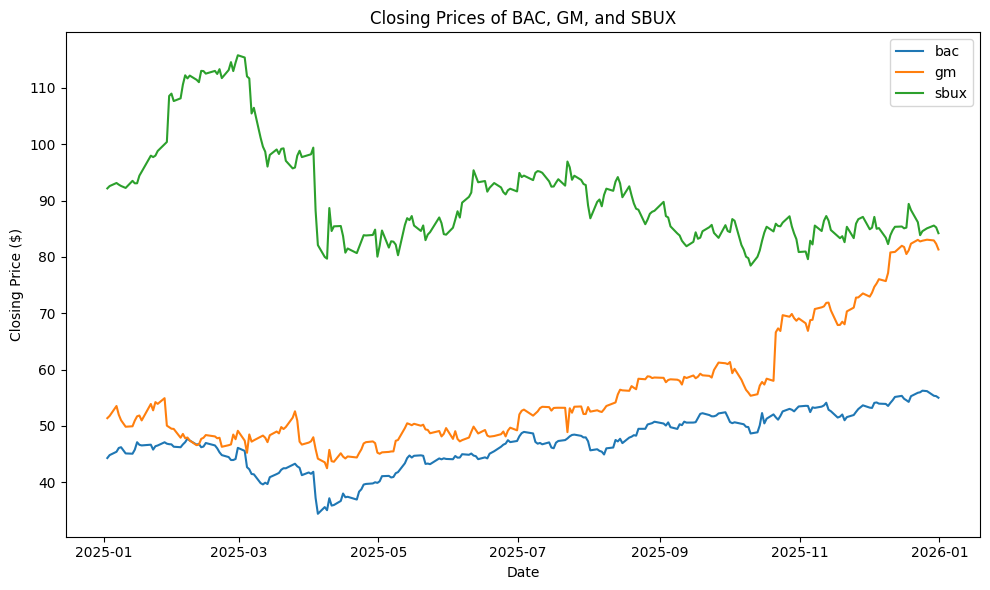

In [1039]:
# Your Solution
# df_bac

df_bac = pd.read_csv("BAC.csv")
df_bac["date"] = pd.to_datetime(df_bac["date"], unit = "s") # Unix timestamps measured in seconds
df_bac = df_bac.set_index("date")

# df_GM
df_gm = pd.read_csv("GM.csv")
df_gm["date"] = pd.to_datetime(df_gm["date"], unit = "s")  
df_gm = df_gm.set_index("date")

# df_sbux
df_sbux = pd.read_csv("SBUX.csv")
df_sbux["date"] = pd.to_datetime(df_sbux["date"], unit = "s")  
df_sbux = df_sbux.set_index("date")

df_stock_prices = pd.DataFrame({"bac": df_bac["close"], "gm": df_gm["close"], "sbux": df_sbux["close"]}, index = df_bac.index)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(df_stock_prices.index, df_stock_prices["bac"], label="bac")
ax.plot(df_stock_prices.index, df_stock_prices["gm"], label="gm")
ax.plot(df_stock_prices.index, df_stock_prices["sbux"], label="sbux")
ax.set_title("Closing Prices of BAC, GM, and SBUX")
ax.set_xlabel("Date")
ax.set_ylabel("Closing Price ($)")
ax.legend()
plt.tight_layout()
plt.show()


In [1040]:
# df_stock_prices

**Problem 15**

**Concept:** *joining `DataFrame`s*


**Task:**

Using the `df_stock_prices` DataFrame from **Problem 14**:
1. Compute the **relative prices** of each stock:
    * Divide all values by the first row of the DataFrame
    * Store the result in a variable named `df_stock_prices_relative`
2. Create a **line plot** of the relative prices.

Your plot should include:
* all three stocks on the same chart
* a title

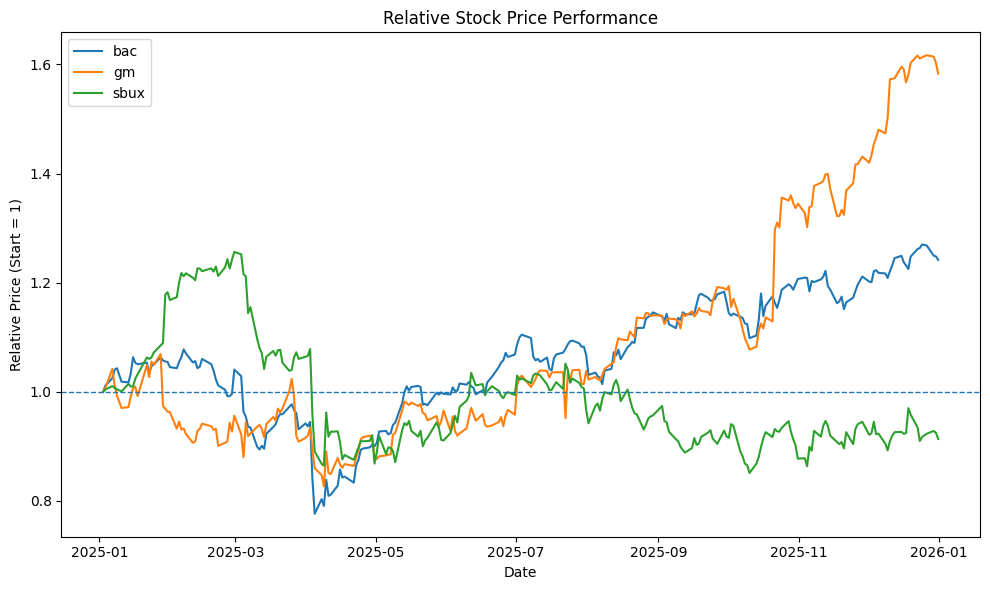

In [1041]:
# Your Solution
# I could also use anonymous function lambda:  df_stock_prices.apply(lambda col: col / col.iloc[0])
df_stock_prices_relative = df_stock_prices[["bac", "gm", "sbux"]] / df_stock_prices.iloc[0]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(df_stock_prices_relative.index, df_stock_prices_relative["bac"], label="bac")
ax.plot(df_stock_prices_relative.index, df_stock_prices_relative["gm"], label="gm")
ax.plot(df_stock_prices_relative.index, df_stock_prices_relative["sbux"], label="sbux")
ax.set_title("Relative Stock Price Performance")
ax.set_xlabel("Date")
ax.set_ylabel("Relative Price (Start = 1)")
ax.legend()
ax.axhline(1, linestyle="--", linewidth=1) # I wnated to present the baseline
plt.tight_layout()
plt.show()